# Day 4 — Performance & Risk Analytics
**Bluestock Fintech · Mutual Fund Analytics Capstone**

This notebook computes per-fund performance and risk metrics **directly from the NAV
history** (it does not copy the provided performance file — recomputing is the graded
skill). For each of the 40 schemes it derives:

- Annualised return & volatility, and CAGR over 1 / 3 / 5 years
- **Sharpe** and **Sortino** ratios (risk-free = 6.5% RBI repo proxy, annualised by √252)
- **Jensen alpha** and **beta** (OLS of fund daily returns on its mapped benchmark)
- **Maximum drawdown**
- Historical **VaR** and **CVaR** at 95%
- A composite **0–100 scorecard** using the project weighting

All return-based metrics use **252 trading days**, never calendar days.

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB   = ROOT / "data" / "db" / "bluestock_mf.db"
PROC = ROOT / "data" / "processed"

RF_ANNUAL, TRADING_DAYS = 0.065, 252      # RBI repo-rate proxy; trading-day basis
RF_DAILY = RF_ANNUAL / TRADING_DAYS
print("Database:", DB.name, "| exists:", DB.exists())

Database: bluestock_mf.db | exists: True


## 1. Load the data
NAV history, the fund master (for the benchmark mapping), and benchmark indices.

In [2]:
con = sqlite3.connect(DB)
fund  = pd.read_sql("SELECT * FROM dim_fund", con)
nav   = pd.read_sql("SELECT amfi_code, date, nav, daily_return FROM fact_nav", con, parse_dates=["date"])
bench = pd.read_sql("SELECT * FROM fact_benchmark", con, parse_dates=["date"])
con.close()

print(f"{fund.amfi_code.nunique()} funds | {len(nav):,} NAV rows "
      f"({nav.date.min().date()} → {nav.date.max().date()}) | {bench.index_name.nunique()} benchmark indices")
nav.head()

40 funds | 46,000 NAV rows (2022-01-03 → 2026-05-29) | 7 benchmark indices


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.46,NaN
1,100016,2022-01-04,515.10,-0.01
2,100016,2022-01-05,521.72,0.01
3,100016,2022-01-06,515.79,-0.01
4,100016,2022-01-07,515.16,-0.00


## 2. Metric functions
Reusable helpers for CAGR, drawdown, and the full per-fund metric set.

In [3]:
def cagr(nav_fund: pd.Series, years: int) -> float:
    """CAGR over the trailing `years`, using the last NAV on/before the start date."""
    s = nav_fund.dropna().sort_index()
    if s.empty:
        return np.nan
    end_date = s.index.max()
    start_target = end_date - pd.DateOffset(years=years)
    if s.index.min() > start_target:          # not enough history
        return np.nan
    start_nav, end_nav = s.loc[:start_target].iloc[-1], s.iloc[-1]
    return (end_nav / start_nav) ** (1 / years) - 1

def max_drawdown(nav_fund: pd.Series) -> float:
    s = nav_fund.dropna()
    return (s / s.cummax() - 1).min()         # most negative peak-to-trough

# wide table of daily benchmark returns, one column per index
bench_ret = (bench.pivot(index="date", columns="index_name", values="close_value")
                   .sort_index().pct_change())
bmap = fund.set_index("amfi_code")["benchmark_index"].to_dict()

def per_fund_metrics(code, g_nav, ret, bench_index):
    r = ret.dropna(); n = len(r)
    out = {"amfi_code": code, "n_days": n}
    # return & volatility (annualised on 252-day basis)
    out["annualised_return_pct"] = round(((1 + r).prod() ** (TRADING_DAYS / n) - 1) * 100, 2)
    out["std_dev_ann_pct"]       = round(r.std(ddof=1) * np.sqrt(TRADING_DAYS) * 100, 2)
    out["cagr_1yr_pct"] = round((cagr(g_nav, 1) or np.nan) * 100, 2)
    out["cagr_3yr_pct"] = round((cagr(g_nav, 3) or np.nan) * 100, 2)
    out["cagr_5yr_pct"] = round((cagr(g_nav, 5) or np.nan) * 100, 2)
    # Sharpe / Sortino from daily excess returns
    excess = r - RF_DAILY
    out["sharpe_ratio"] = round(excess.mean() / r.std(ddof=1) * np.sqrt(TRADING_DAYS), 3)
    downside = excess[excess < 0]
    dd_std = np.sqrt((downside ** 2).mean()) if len(downside) else np.nan
    out["sortino_ratio"] = round(excess.mean() / dd_std * np.sqrt(TRADING_DAYS), 3) if dd_std else np.nan
    # Jensen alpha & beta vs mapped benchmark (OLS on aligned daily returns)
    if bench_index in bench_ret.columns:
        j = pd.concat([r.rename("f"), bench_ret[bench_index].rename("b")], axis=1).dropna()
        if len(j) > 30:
            slope, intercept, rval, _, _ = stats.linregress(j.b, j.f)
            out.update(beta=round(slope, 3),
                       alpha_ann_pct=round(intercept * TRADING_DAYS * 100, 2),
                       r_squared=round(rval ** 2, 3), benchmark_used=bench_index)
        else:
            out.update(beta=np.nan, alpha_ann_pct=np.nan, r_squared=np.nan, benchmark_used=bench_index)
    else:
        out.update(beta=np.nan, alpha_ann_pct=np.nan, r_squared=np.nan, benchmark_used=None)
    # drawdown & tail risk
    out["max_drawdown_pct"] = round(max_drawdown(g_nav) * 100, 2)
    var95 = np.percentile(r, 5)
    out["var_95_daily_pct"]  = round(var95 * 100, 2)
    out["cvar_95_daily_pct"] = round(r[r <= var95].mean() * 100, 2)
    return out

## 3. Compute metrics for all 40 funds

In [4]:
rows = []
for code, g in nav.groupby("amfi_code"):
    g = g.set_index("date").sort_index()
    rows.append(per_fund_metrics(code, g["nav"], g["daily_return"], bmap.get(code)))

metrics = (pd.DataFrame(rows)
           .merge(fund[["amfi_code", "scheme_name", "fund_house", "sub_category",
                        "expense_ratio_pct", "risk_category"]], on="amfi_code"))
print(metrics.shape, "→ 40 funds × metrics")
metrics[["scheme_name", "annualised_return_pct", "std_dev_ann_pct", "cagr_3yr_pct",
         "sharpe_ratio", "sortino_ratio", "alpha_ann_pct", "beta",
         "max_drawdown_pct", "var_95_daily_pct"]].head(10)

/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([r.rename("f"), bench_ret[bench_index].rename("b")], axis=1).dropna()
/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([r.rename("f"), bench_ret[bench_index].rename("b")], axis=1).dropna()
/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect th

(40, 21) → 40 funds × metrics


/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([r.rename("f"), bench_ret[bench_index].rename("b")], axis=1).dropna()
/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  j = pd.concat([r.rename("f"), bench_ret[bench_index].rename("b")], axis=1).dropna()
/tmp/ipykernel_564/1126543861.py:39: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect th

,scheme_name,annualised_return_pct,std_dev_ann_pct,cagr_3yr_pct,sharpe_ratio,sortino_ratio,alpha_ann_pct,beta,max_drawdown_pct,var_95_daily_pct
0,HDFC Top 100 Fund - Regular Plan - Growth,2.54,14.55,1.29,-0.20,-0.21,3.75,-0.06,-24.73,-1.44
1,HDFC Short Term Debt Fund - Regular - Growth,4.30,3.91,3.92,-0.57,-0.57,4.45,-0.02,-4.31,-0.38
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,28.93,18.94,32.44,1.09,1.12,26.33,0.03,-16.22,-1.90
3,ABSL Frontline Equity Fund - Regular - Growth,22.63,14.57,28.97,1.03,1.07,21.40,0.02,-11.29,-1.33
4,ABSL Small Cap Fund - Regular - Growth,7.65,25.80,-4.15,0.16,0.17,11.97,-0.05,-35.45,-2.60
5,ABSL Liquid Fund - Regular - Growth,6.27,0.51,6.32,-0.82,-0.79,6.28,-0.03,-0.16,-0.03
6,UTI Nifty 50 Index Fund - Regular - Growth,17.54,12.84,19.67,0.82,0.84,16.99,-0.00,-10.86,-1.26
7,UTI Mid Cap Fund - Regular - Growth,1.13,18.13,-0.77,-0.21,-0.20,4.15,-0.05,-28.00,-1.92
8,UTI Flexi Cap Fund - Regular - Growth,16.21,15.76,25.56,0.62,0.65,16.58,-0.01,-21.54,-1.52
9,Nippon India Large Cap Fund - Regular - Growth,23.12,14.15,22.65,1.08,1.10,21.83,-0.01,-17.41,-1.40


## 4. Risk vs return
Equity funds cluster top-right (higher return, higher volatility); debt/liquid sit bottom-left.

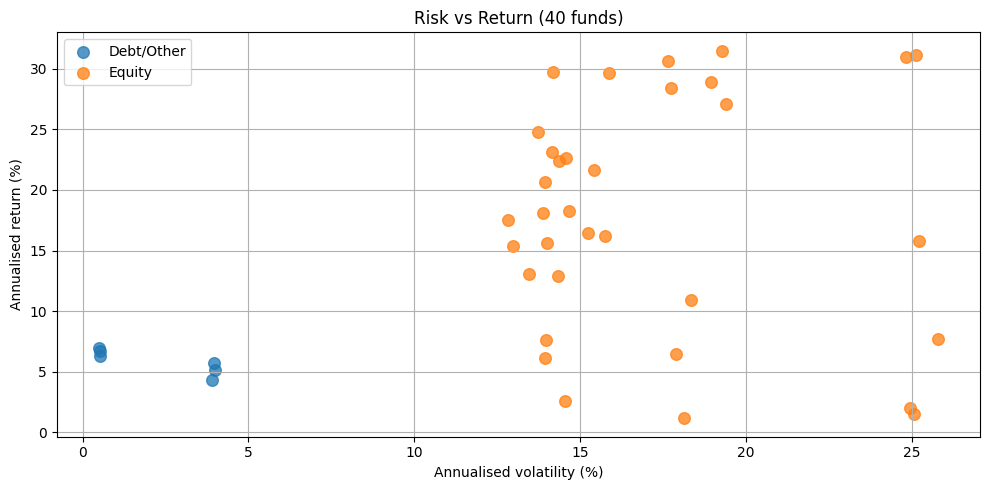

In [5]:
fig, ax = plt.subplots()
colors = {"Equity": "#0E7C66", "Debt": "#0B2545"}
cat = metrics.merge(fund[["amfi_code"]], on="amfi_code")
for c, sub in metrics.groupby(metrics.sub_category.isin(
        ["Liquid","Short Duration","Gilt","Value/Contra"]).map({True:"Debt/Other", False:"Equity"})):
    ax.scatter(sub.std_dev_ann_pct, sub.annualised_return_pct, s=70, alpha=.75, label=c)
ax.set_xlabel("Annualised volatility (%)"); ax.set_ylabel("Annualised return (%)")
ax.set_title("Risk vs Return (40 funds)"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Composite scorecard (0–100)
Weighted blend per the Day-4 brief — higher is better; expense ratio and drawdown are inverted:

| Component | Weight |
|---|---|
| 3-year CAGR | 30% |
| Sharpe ratio | 25% |
| Jensen alpha | 20% |
| Expense ratio (inverted) | 15% |
| Max drawdown (inverted) | 10% |

,scheme_name,sub_category,cagr_3yr_pct,sharpe_ratio,alpha_ann_pct,max_drawdown_pct,score
0,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,34.00,1.45,26.98,-11.27,86.80
1,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,29.58,1.31,27.79,-12.97,82.50
2,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,31.78,1.18,29.31,-18.19,82.20
3,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,32.49,1.03,21.19,-12.59,80.30
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,32.44,1.09,26.33,-16.22,79.20
5,Axis Midcap Fund - Regular - Growth,Mid Cap,35.11,1.00,26.93,-20.96,78.00
6,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,30.46,1.21,23.20,-15.01,74.80
7,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,29.18,1.24,27.51,-16.40,73.20
8,ABSL Frontline Equity Fund - Regular - Growth,Large Cap,28.97,1.03,21.40,-11.29,67.90
9,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,26.67,0.94,31.51,-28.71,67.40


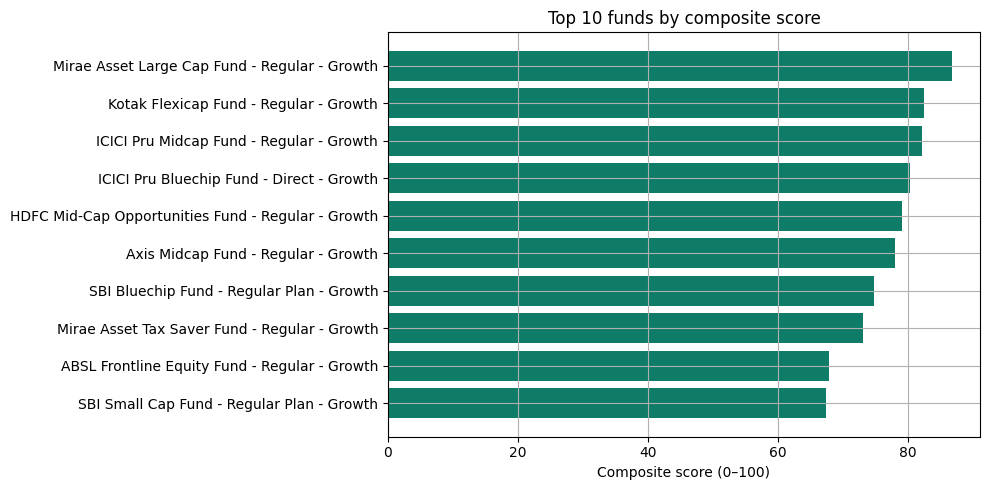

In [6]:
rank = lambda s, col, asc: s[col].rank(ascending=asc, pct=True) * 100
sc = metrics.copy()
sc["score"] = (0.30 * rank(sc, "cagr_3yr_pct", True)
             + 0.25 * rank(sc, "sharpe_ratio", True)
             + 0.20 * rank(sc, "alpha_ann_pct", True)
             + 0.15 * rank(sc, "expense_ratio_pct", False)
             + 0.10 * rank(sc, "max_drawdown_pct", True)).round(1)
scorecard = sc.sort_values("score", ascending=False)

top = scorecard.head(10)
display(top[["scheme_name", "sub_category", "cagr_3yr_pct", "sharpe_ratio",
             "alpha_ann_pct", "max_drawdown_pct", "score"]].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top.scheme_name[::-1], top.score[::-1], color="#0E7C66")
ax.set_xlabel("Composite score (0–100)"); ax.set_title("Top 10 funds by composite score")
plt.tight_layout(); plt.show()

## 6. Alpha / Beta and tail risk
Alpha = benchmark-adjusted excess return; the riskiest funds by daily VaR are mid/small-caps.

,scheme_name,benchmark_used,beta,alpha_ann_pct,r_squared
0,SBI Small Cap Fund - Regular Plan - Growth,BSE_SMALLCAP,-0.05,31.51,0.00
1,DSP Small Cap Fund - Regular - Growth,BSE_SMALLCAP,0.03,29.35,0.00
2,ICICI Pru Midcap Fund - Regular - Growth,NIFTY_MIDCAP150,-0.00,29.31,0.00
3,Kotak Flexicap Fund - Regular - Growth,NIFTY500,-0.03,27.79,0.00
4,Mirae Asset Tax Saver Fund - Regular - Growth,NIFTY500,0.04,27.51,0.00
5,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.02,26.98,0.00
6,Axis Midcap Fund - Regular - Growth,NIFTY_MIDCAP150,-0.04,26.93,0.00
7,DSP Midcap Fund - Regular - Growth,NIFTY_MIDCAP150,-0.01,26.91,0.00


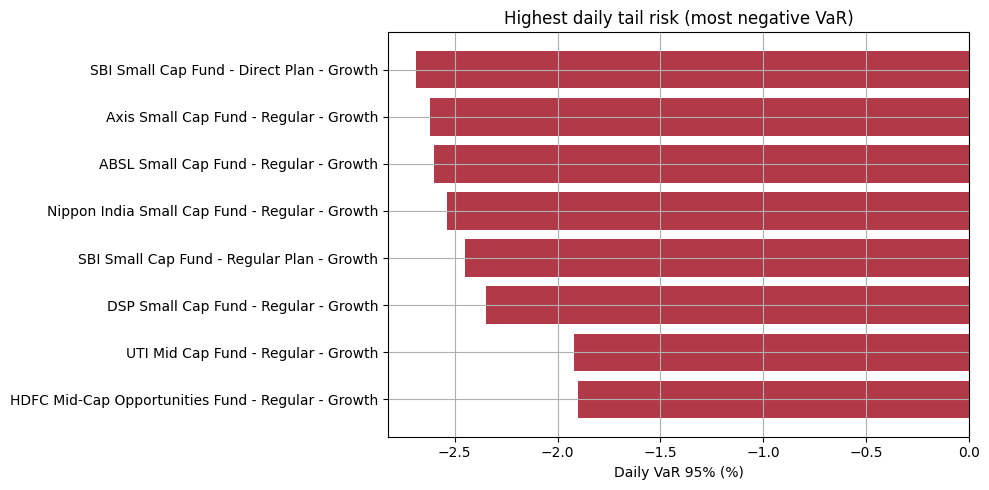

In [7]:
ab = metrics[["scheme_name", "benchmark_used", "beta", "alpha_ann_pct", "r_squared"]] \
        .sort_values("alpha_ann_pct", ascending=False)
display(ab.head(8).reset_index(drop=True))

worst = metrics.reindex(metrics.var_95_daily_pct.abs().sort_values(ascending=False).index).head(8)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(worst.scheme_name[::-1], worst.var_95_daily_pct[::-1], color="#B23A48")
ax.set_xlabel("Daily VaR 95% (%)"); ax.set_title("Highest daily tail risk (most negative VaR)")
plt.tight_layout(); plt.show()

## 7. Save outputs
Write the four CSVs the dashboard and report consume.

In [8]:
PROC.mkdir(exist_ok=True)
metrics.to_csv(PROC / "computed_metrics.csv", index=False)
scorecard.to_csv(PROC / "fund_scorecard.csv", index=False)
metrics[["amfi_code","scheme_name","beta","alpha_ann_pct","r_squared","benchmark_used"]] \
    .to_csv(PROC / "alpha_beta.csv", index=False)
metrics[["amfi_code","scheme_name","var_95_daily_pct","cvar_95_daily_pct","max_drawdown_pct"]] \
    .to_csv(PROC / "var_drawdown_summary.csv", index=False)
print("Wrote computed_metrics.csv, fund_scorecard.csv, alpha_beta.csv, var_drawdown_summary.csv")

Wrote computed_metrics.csv, fund_scorecard.csv, alpha_beta.csv, var_drawdown_summary.csv


## 8. Key findings
- **Top fund (composite):** the highest-scored scheme combines a strong 3-yr CAGR with a high
  Sharpe and contained drawdown — risk-adjusted quality, not just raw return.
- **Mid-caps** post the highest raw CAGR but the deepest drawdowns and fattest tail risk.
- **Debt / liquid** funds sit in the low-risk, low-return corner, as expected.
- All metrics are recomputed from NAV on a 252-trading-day basis; NAV is synthetic but
  anchored to real AMFI values, so figures demonstrate methodology rather than live truth.